In [8]:
!pip install rdkit tqdm

In [9]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
tqdm.pandas()

In [10]:
df = pd.read_csv(
    "/kaggle/input/datasets/snrupendra2/chembl-36-chemreps/chembl_36_chemreps.txt",
    sep="\t",
    usecols=["chembl_id", "canonical_smiles"]
)
print(f"Raw Shape: {df.shape}")
df.head()

Raw Shape: (2854815, 2)


,chembl_id,canonical_smiles
0,CHEMBL153534,Cc1cc(-c2csc(N=C(N)N)n2)cn1C
1,CHEMBL440060,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...
2,CHEMBL440245,CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...
3,CHEMBL440249,CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...
4,CHEMBL405398,Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1


In [11]:
print("=== Dataset Info ===")
print(f"Total rows        : {len(df)}")
print(f"Null in chembl_id : {df['chembl_id'].isnull().sum()}")
print(f"Null in smiles    : {df['canonical_smiles'].isnull().sum()}")
print(f"Unique chembl_id  : {df['chembl_id'].nunique()}")
print(f"Unique smiles     : {df['canonical_smiles'].nunique()}")

=== Dataset Info ===
Total rows        : 2854815
Null in chembl_id : 0
Null in smiles    : 0
Unique chembl_id  : 2854815
Unique smiles     : 2854654


=== SMILES Length Stats ===
count    2.854815e+06
mean     5.864996e+01
std      4.445540e+01
min      1.000000e+00
25%      4.000000e+01
50%      5.100000e+01
75%      6.400000e+01
max      2.093000e+03
Name: smiles_length, dtype: float64


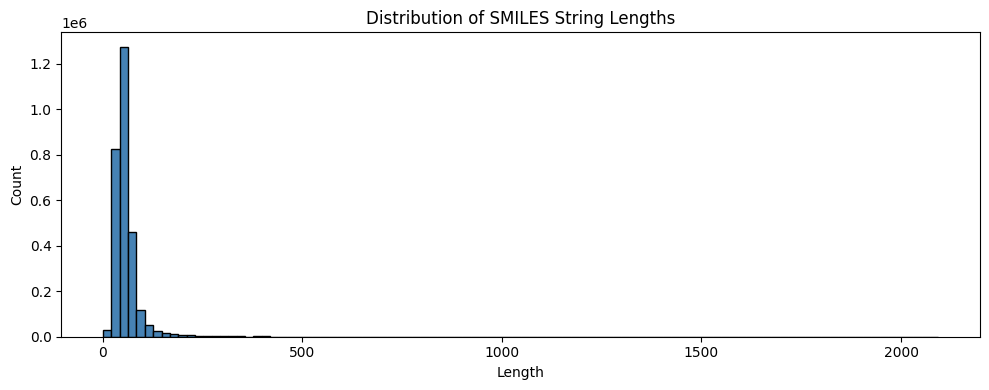

In [12]:
df['smiles_length'] = df['canonical_smiles'].astype(str).apply(len)

print("=== SMILES Length Stats ===")
print(df['smiles_length'].describe())

plt.figure(figsize=(10, 4))
plt.hist(df['smiles_length'], bins=100, color='steelblue', edgecolor='black')
plt.title("Distribution of SMILES String Lengths")
plt.xlabel("Length")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [13]:
df = df.dropna(subset=["chembl_id", "canonical_smiles"])
df = df.drop_duplicates(subset=["canonical_smiles"])
df = df.reset_index(drop=True)

print(f"Clean shape: {df.shape}")
df.head()

Clean shape: (2854654, 3)


,chembl_id,canonical_smiles,smiles_length
0,CHEMBL153534,Cc1cc(-c2csc(N=C(N)N)n2)cn1C,28
1,CHEMBL440060,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...,492
2,CHEMBL440245,CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...,608
3,CHEMBL440249,CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...,466
4,CHEMBL405398,Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1,38


In [14]:
def is_valid_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        return mol is not None
    except:
        return False

df['valid'] = df['canonical_smiles'].progress_apply(is_valid_smiles)

print(f"Valid   : {df['valid'].sum()}")
print(f"Invalid : {(~df['valid']).sum()}")

df = df[df['valid']].drop(columns=['valid', 'smiles_length']).reset_index(drop=True)
print(f"Final shape after validation: {df.shape}")

 35%|███▌      | 1012681/2854654 [05:04<07:57, 3858.55it/s][11:48:03] WARNING: not removing hydrogen atom without neighbors
[11:48:03] WARNING: not removing hydrogen atom without neighbors
 96%|█████████▌| 2726393/2854654 [13:37<00:41, 3092.34it/s][11:56:37] WARNING: not removing hydrogen atom without neighbors
[11:56:37] WARNING: not removing hydrogen atom without neighbors
[11:56:37] WARNING: not removing hydrogen atom without neighbors
100%|█████████▉| 2854363/2854654 [14:19<00:00, 2959.91it/s][11:57:19] WARNING: not removing hydrogen atom without neighbors
[11:57:19] WARNING: not removing hydrogen atom without neighbors
[11:57:19] WARNING: not removing hydrogen atom without neighbors
[11:57:19] WARNING: not removing hydrogen atom without neighbors
[11:57:19] Explicit valence for atom # 1 P, 7, is greater than permitted
[11:57:19] Explicit valence for atom # 34 P, 7, is greater than permitted
100%|██████████| 2854654/2854654 [14:20<00:00, 3319.30it/s]


Valid   : 2854639
Invalid : 15
Final shape after validation: (2854639, 2)


In [15]:
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fingerprint(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return None
        fp = gen.GetFingerprintAsNumPy(mol)  # returns uint8 array of length 2048
        return fp.astype(np.uint8)
    except:
        return None

print("Generating fingerprints...")
df['fingerprint'] = df['canonical_smiles'].progress_apply(smiles_to_fingerprint)

failed = df['fingerprint'].isnull().sum()
print(f"Failed to generate: {failed}")

df = df[df['fingerprint'].notnull()].reset_index(drop=True)
print(f"Final molecules with fingerprints: {len(df)}")

Generating fingerprints...


 35%|███▌      | 1012690/2854639 [07:31<11:41, 2627.51it/s][12:04:51] WARNING: not removing hydrogen atom without neighbors
[12:04:51] WARNING: not removing hydrogen atom without neighbors
 96%|█████████▌| 2726633/2854639 [20:07<01:00, 2100.66it/s][12:17:27] WARNING: not removing hydrogen atom without neighbors
[12:17:27] WARNING: not removing hydrogen atom without neighbors
[12:17:27] WARNING: not removing hydrogen atom without neighbors
100%|█████████▉| 2854540/2854639 [21:09<00:00, 2044.78it/s][12:18:29] WARNING: not removing hydrogen atom without neighbors
[12:18:29] WARNING: not removing hydrogen atom without neighbors
[12:18:29] WARNING: not removing hydrogen atom without neighbors
[12:18:29] WARNING: not removing hydrogen atom without neighbors
100%|██████████| 2854639/2854639 [21:09<00:00, 2248.45it/s]


Failed to generate: 0
Final molecules with fingerprints: 2854639


In [16]:
lengths = df['fingerprint'].apply(len)
print(f"Min length: {lengths.min()}")
print(f"Max length: {lengths.max()}")
print(f"All exactly 2048: {(lengths == 2048).all()}")

Min length: 2048
Max length: 2048
All exactly 2048: True


In [17]:
def pack_to_uint64(fp_array):
    # fp_array: 2048 individual bits as uint8 (0 or 1)
    # packbits: packs 8 bits into 1 byte → 256 bytes
    # view as uint64: 256 bytes → 32 uint64 words
    packed_bytes = np.packbits(fp_array)           # shape: (256,) uint8
    return packed_bytes.view(np.uint64)             # shape: (32,)  uint64

# Stack all fingerprints → (N, 2048)
fp_matrix = np.stack(df['fingerprint'].values)
print(f"Fingerprint matrix shape: {fp_matrix.shape}")

# Pack each row → (N, 32)
packed = np.array([pack_to_uint64(row) for row in fp_matrix], dtype=np.uint64)
print(f"Packed matrix shape: {packed.shape}")

# Verify every row is exactly 32 words
assert packed.shape[1] == 32, "ERROR: Not all fingerprints packed to 32 uint64 words!"
print("All fingerprints correctly packed to 32 uint64 words ✓")

# Save to binary
output_bin = "/kaggle/working/chembl_fingerprints.bin"
packed.tofile(output_bin)
print(f"Saved binary: {output_bin}  ({os.path.getsize(output_bin) / 1e6:.1f} MB)")

Fingerprint matrix shape: (2854639, 2048)
Packed matrix shape: (2854639, 32)
All fingerprints correctly packed to 32 uint64 words ✓
Saved binary: /kaggle/working/chembl_fingerprints.bin  (730.8 MB)


In [18]:
# Save fingerprint as hex string so it's stored in CSV and verifiable
df['fingerprint_hex'] = df['fingerprint'].apply(
    lambda fp: np.packbits(fp).tobytes().hex()
)

metadata = df[['chembl_id', 'canonical_smiles', 'fingerprint_hex']]
output_csv = "/kaggle/working/chembl_metadata.csv"
metadata.to_csv(output_csv, index=False)

print(f"Metadata saved: {output_csv}")
print(f"Rows saved: {len(metadata)}")
metadata.head()

Metadata saved: /kaggle/working/chembl_metadata.csv
Rows saved: 2854639


,chembl_id,canonical_smiles,fingerprint_hex
0,CHEMBL153534,Cc1cc(-c2csc(N=C(N)N)n2)cn1C,0010200000000000000000000000000000080000000000...
1,CHEMBL440060,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...,40100000004000000001c00000000c0000088100000400...
2,CHEMBL440245,CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...,40000000000100000001c0000400140000089100010000...
3,CHEMBL440249,CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...,40000010004100001000800004001400000a0000000400...
4,CHEMBL405398,Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1,0000000000000060000080000000000000000000000020...


In [19]:
N = len(df)
loaded = np.fromfile("/kaggle/working/chembl_fingerprints.bin", dtype=np.uint64)

print(f"Total uint64 values loaded : {len(loaded)}")
print(f"Expected (N x 32)          : {N * 32}")
print(f"Match                      : {len(loaded) == N * 32}")

loaded = loaded.reshape(N, 32)
print(f"Reshaped to                : {loaded.shape}")
print("Binary file verified ✓")

Total uint64 values loaded : 91348448
Expected (N x 32)          : 91348448
Match                      : True
Reshaped to                : (2854639, 32)
Binary file verified ✓


In [20]:
from IPython.display import FileLink, display

display(FileLink('chembl_fingerprints.bin'))
display(FileLink('chembl_metadata.csv'))

/kaggle/working/chembl_fingerprints.bin

/kaggle/working/chembl_metadata.csv